# Increase Fairness in Your Machine Learning Project with Disparate Impact Analysis using Pandas, Numpy, H2O, and Datatable

#### Assess if your **multinomial** machine learning model is treating different groups of people similarly or differently

Fairness is an incredibly important, but highly complex entity. So much so that leading scholars have yet to agree on a strict definition. However, there is a practical way to discuss and handle observational fairness, or how your model predictions affect different groups of people. This procedure is often known as disparate impact analysis (DIA). DIA is far from perfect, as it relies heavily on user-defined thresholds and reference levels for disparity and does not attempt to remediate disparity or provide information on sources of disparity, but it is a fairly straightforward method to quantify your model’s behavior across sensitive demographic segments or other potentially interesting groups of observations. DIA is also an accepted, regulation-compliant tool for fair-lending purposes in the U.S. financial services industry. If it’s good enough for multibillion-dollar credit portfolios, it’s probably good enough for your project.

This example DIA notebook starts by training a multinomial gradient boosting machine (GBM) classifier on the UCI creditcard default data using the popular open source library, h2o. Since this is a multinomial problem with several outcomes of interest, we will use a ranking technique by utilizing standardized mean difference (SMD) to pick an outcome to look at in more detail with traditional disparate impact analysis, which is ultimately fit for binary classification problems.

#### Python imports
In general, NumPy and Pandas will be used for data manipulation purposes and h2o will be used for modeling tasks. 

In [1]:
import hmli                                        
from hmli.estimators.gbm import H2OGradientBoostingEstimator       

import collections
import numpy as np   
import pandas as pd 
import datatable as dt
from datatable import f
from mli.fairness.disparate_impact_analysis import BinaryDisparateImpactAnalysis
from mli.utils.fairness_utils import get_prroc_dt, smd_multinomial
%matplotlib inline   

#### Start `h2o`
H2O is both a library and a server. The machine learning algorithms in the library take advantage of the multithreaded and distributed architecture provided by the server to train machine learning algorithms extremely efficiently. The API for the library was imported above in cell 1, but the server still needs to be started.

In [2]:
hmli.init(max_mem_size='2G')       
hmli.remove_all()                  

Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
  Java Version: java version "1.8.0_221"; Java(TM) SE Runtime Environment (build 1.8.0_221-b11); Java HotSpot(TM) 64-Bit Server VM (build 25.221-b11, mixed mode)
  Starting server from /Users/ngill/Desktop/mli-2/mli2_env/lib/python3.6/site-packages/hmli/backend/bin/hmli.jar
  Ice root: /var/folders/4f/jnv5n85x51v1r8f9n4q8bzl80000gp/T/tmpp48ak7cn
  JVM stdout: /var/folders/4f/jnv5n85x51v1r8f9n4q8bzl80000gp/T/tmpp48ak7cn/hmli_ngill_started_from_python.out
  JVM stderr: /var/folders/4f/jnv5n85x51v1r8f9n4q8bzl80000gp/T/tmpp48ak7cn/hmli_ngill_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O cluster uptime:,01 secs
H2O cluster timezone:,America/Los_Angeles
H2O data parsing timezone:,UTC
H2O cluster version:,3.28.0.1
H2O cluster version age:,5 months and 18 days !!!
H2O cluster name:,H2O_from_python_ngill_jtl0ue
H2O cluster total nodes:,1
H2O cluster free memory:,1.778 Gb
H2O cluster total cores:,12
H2O cluster allowed cores:,12
H2O cluster status:,"accepting new members, healthy"


## 1. Download, explore, and prepare UCI credit card default data

UCI credit card default data: https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

The UCI credit card default data contains demographic and payment information about credit card customers in Taiwan in the year 2005. The data set contains 22 input variables: 

* **`LIMIT_BAL`**: Amount of given credit (NT dollar)
* **`SEX`**: 1 = male; 2 = female 
* **`MARRIAGE`**: 1 = married; 2 = single; 3 = others
* **`AGE`**: Age in years 
* **`PAY_0`, `PAY_2` - `PAY_6`**: History of past payment; `PAY_0` = the repayment status in September, 2005; `PAY_2` = the repayment status in August, 2005; ...; `PAY_6` = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; ...; 8 = payment delay for eight months; 9 = payment delay for nine months and above. 
* **`BILL_AMT1` - `BILL_AMT6`**: Amount of bill statement (NT dollar). `BILL_AMNT1` = amount of bill statement in September, 2005; `BILL_AMT2` = amount of bill statement in August, 2005; ...; `BILL_AMT6` = amount of bill statement in April, 2005. 
* **`PAY_AMT1` - `PAY_AMT6`**: Amount of previous payment (NT dollar). `PAY_AMT1` = amount paid in September, 2005; `PAY_AMT2` = amount paid in August, 2005; ...; `PAY_AMT6` = amount paid in April, 2005. 

These 22 input variables are used to predict the target variable, which is the education level of an observation.

Because h2o accepts both numeric and character inputs, some variables will be recoded into more transparent character values.

#### Import data and clean

In [3]:
# import XLS file
url = '../data/predictive/creditcard.csv'
data = pd.read_csv(url)

# remove spaces from target column name 
data = data.rename(columns={'default payment next month': 'DEFAULT_NEXT_MONTH'}) 

In [4]:
# See first 5 rows of dataset
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,1,20000,2,2,1,24,-2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,1,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,2,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### Assign modeling roles
The shorthand name `y` is assigned to the prediction target. `X` is assigned to all other input variables in the credit card default data except the row indentifier, `ID`.

In [5]:
# assign target and inputs for GBM
y = 'EDUCATION'
X = [name for name in data.columns if name not in [y, 'ID', 'DEFAULT_NEXT_MONTH', 'SEX', 'MARRIAGE', 'AGE']]
print('y =', y)
print('X =', X)

y = EDUCATION
X = ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


#### Helper function for recoding values in the UCI credict card default data
This simple function maps longer, more understandable character string values from the UCI credit card default data dictionary to the original integer values of the input variables found in the dataset. These character values can be used directly in h2o decision tree models, and the function returns the original Pandas DataFrame as an h2o object, an H2OFrame. H2o models cannot run on Pandas DataFrames. They require H2OFrames.

In [6]:
def recode_cc_data(frame):
    
    """ Recodes numeric categorical variables into categorical character variables
    with more transparent values. 
    
    Args:
        frame: Pandas DataFrame version of UCI credit card default data.
        
    Returns: 
        H2OFrame with recoded values.
        
    """
    
    # define recoded values
    sex_dict = {1:'male', 2:'female'}
    education_dict = {0:'other', 1:'graduate school', 2:'university', 3:'high school', 
                      4:'other', 5:'other', 6:'other'}
    marriage_dict = {0:'other', 1:'married', 2:'single', 3:'divorced'}
    pay_dict = {-2:'no consumption', -1:'pay duly', 0:'use of revolving credit', 1:'1 month delay', 
                2:'2 month delay', 3:'3 month delay', 4:'4 month delay', 5:'5 month delay', 6:'6 month delay', 
                7:'7 month delay', 8:'8 month delay', 9:'9+ month delay'}
    
    # recode values using Pandas apply() and anonymous function
    frame['SEX'] = frame['SEX'].apply(lambda i: sex_dict[i])
    frame['EDUCATION'] = frame['EDUCATION'].apply(lambda i: education_dict[i])    
    frame['MARRIAGE'] = frame['MARRIAGE'].apply(lambda i: marriage_dict[i]) 
    for name in frame.columns:
        if name in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
            frame[name] = frame[name].apply(lambda i: pay_dict[i])            
                
    return hmli.H2OFrame(frame)

data = recode_cc_data(data)

Parse progress: |█████████████████████████████████████████████████████████| 100%


#### Ensure target is handled as a categorical variable

In h2o, a numeric variable can be treated as numeric or categorical. The target variable `DEFAULT_NEXT_MONTH` takes on values of `0` or `1`. To ensure this numeric variable is treated as a categorical variable, the `asfactor()` function is used to explicitly declare that it is a categorical variable. 

In [7]:
data[y] = data[y].asfactor() 

#### Display descriptive statistics
The h2o `describe()` function displays a brief description of the credit card default data. For the categorical input variables `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, and `PAY_0`-`PAY_6`, the new character values created above in cell 5 are visible. Basic descriptive statistics are displayed for numeric inputs. Also, it's easy to see there are no missing values in this dataset, which will be an important consideration for calculating LOCO values in section 5 and 6.

In [8]:
data[X + [y]].describe()

Rows:10000
Cols:20




,LIMIT_BAL,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION
type,int,enum,enum,enum,enum,enum,enum,int,int,int,int,int,int,int,int,int,int,int,int,enum
mins,10000.0,,,,,,,-15308.0,-33350.0,-34041.0,-170000.0,-28335.0,-339603.0,0.0,0.0,0.0,0.0,0.0,0.0,
mean,165877.59999999995,,,,,,,49852.872399999935,47950.35280000005,45215.7954999997,40437.75879999991,39172.90310000002,37663.649699999856,5618.903200000025,5782.403200000006,4536.424100000022,4678.900799999997,4832.089199999977,5324.097999999997,
maxs,1000000.0,,,,,,,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0,405016.0,1684259.0,896040.0,497000.0,379267.0,528666.0,
sigma,130049.37024880279,,,,,,,71798.37047110994,69644.75803183227,67735.22261987331,61116.11901808878,59252.276301784426,58892.389641466965,15459.211686241506,23963.138610253776,16073.050516847505,14578.848908549273,15220.329929642146,18578.265053783623,
zeros,0,,,,,,,700,879,1024,1095,1216,1456,1781,1910,2108,2213,2293,2561,
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,20000.0,no consumption,2 month delay,pay duly,pay duly,no consumption,no consumption,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,university
1,120000.0,pay duly,2 month delay,use of revolving credit,use of revolving credit,use of revolving credit,2 month delay,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,university
2,90000.0,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,university


## 2. Train an H2O GBM multinomial classifier

#### Split data into training and test sets for early stopping
The credit card default data is split into training and test sets to monitor and prevent overtraining. Reproducibility is also an important factor in creating trustworthy models, and randomly splitting datasets can introduce randomness in model predictions and other results. A random seed is used here to ensure the data split is reproducible.

In [9]:
# # split into training and validation
# train, test = data.split_frame([0.7], seed=12345)

# # summarize split
# print('Train data rows = %d, columns = %d' % (train.shape[0], train.shape[1]))
# print('Test data rows = %d, columns = %d' % (test.shape[0], test.shape[1]))

#### Train h2o GBM classifier
Many tuning parameters must be specified to train a GBM using h2o. Typically a grid search would be performed to identify the best parameters for a given modeling task using the `H2OGridSearch` class. For brevity's sake, a previously-discovered set of good tuning parameters are specified here. Because gradient boosting methods typically resample training data, an additional random seed is also specified for the h2o GBM using the `seed` parameter to create reproducible predictions, error rates, and variable importance values. To avoid overfitting, the `stopping_rounds` parameter is used to stop the training process after the test error fails to decrease for 5 iterations. 

In [10]:
# initialize GBM model
model = H2OGradientBoostingEstimator(ntrees=150,            # maximum 150 trees in GBM
                                     max_depth=4,           # trees can have maximum depth of 4
                                     sample_rate=0.9,       # use 90% of rows in each iteration (tree)
                                     col_sample_rate=0.9,   # use 90% of variables in each iteration (tree)
                                     #balance_classes=True, # sample to balance 0/1 distribution of target - can help LOCO
                                     stopping_rounds=5,     # stop if validation error does not decrease for 5 iterations (trees)
                                     score_tree_interval=1, # for reproducibility, set higher for bigger data
                                     model_id='dia_gbm',    # for locating the model in Flow UI 
                                     seed=12345)            # for reproducibility

# train a GBM model
model.train(y=y, x=X, training_frame=data)

# print AUC
print('GBM Test AUC = %.2f' % model.logloss())

# uncomment to see model details
# print(model) 

gbm Model Build progress: |███████████████████████████████████████████████| 100%
GBM Test AUC = 0.85


#### Display variable importance
During training, the h2o GBM aggregates the improvement in error caused by each split in each decision tree across all the decision trees in the ensemble classifier. These values are attributed to the input variable used in each split and give an indication of the contribution each input variable makes toward the model's predictions. The variable importance ranking should be parsimonious with human domain knowledge and reasonable expectations. In this case, a customer's most recent payment behavior, `PAY_0`, is by far the most important variable followed by their second most recent payment, `PAY_2`, and third most recent payment, `PAY_3`, behavior. This result is well-aligned with business practices in credit lending: people who miss their most recent payments are likely to default soon.

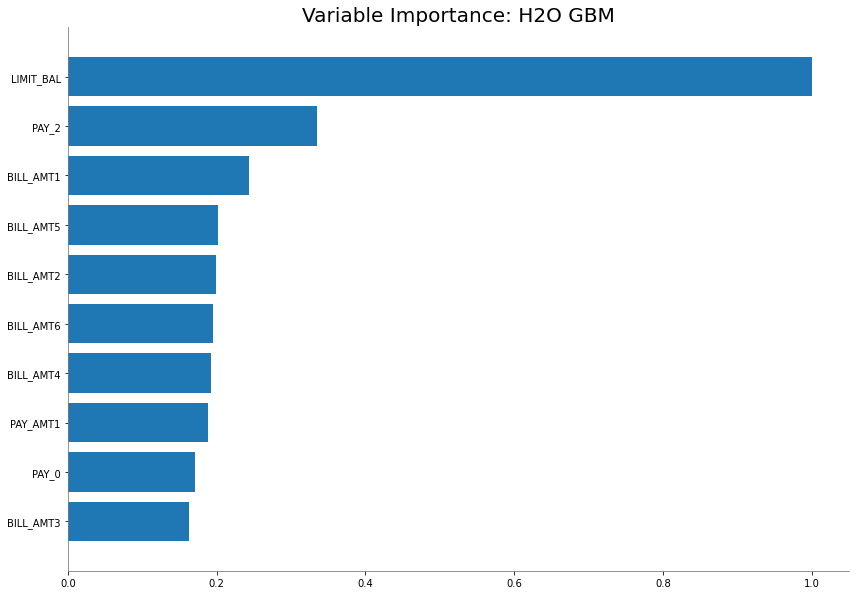

In [11]:
model.varimp_plot()

In sections below this notebook will assess whether the GBM is making disparate predictions for customers across educational levels. For now, it's a somewhat heartening sign that the GBM is not placing high importance on the `EDUCATION` variable.

In [12]:
perf_of_model = model.model_performance()
perf_of_model


ModelMetricsMultinomial: gbm
** Reported on train data. **

MSE: 0.3099560098851782
RMSE: 0.5567369305921588
LogLoss: 0.8466965804419558
Mean Per-Class Error: 0.5320762776282448

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,graduate school,high school,other,university,Error,Rate
0,2381.0,7.0,0.0,1326.0,0.358912,"1,333 / 3,714"
1,344.0,147.0,0.0,1099.0,0.907547,"1,443 / 1,590"
2,20.0,0.0,35.0,53.0,0.675926,73 / 108
3,851.0,2.0,0.0,3735.0,0.185920,"853 / 4,588"
4,3596.0,156.0,35.0,6213.0,0.370200,"3,702 / 10,000"



Top-4 Hit Ratios: 


,k,hit_ratio
0,1,0.6298
1,2,0.8899
2,3,0.9949
3,4,1.0000


In [13]:
perf_of_model.confusion_matrix()


Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,graduate school,high school,other,university,Error,Rate
0,2381.0,7.0,0.0,1326.0,0.358912,"1,333 / 3,714"
1,344.0,147.0,0.0,1099.0,0.907547,"1,443 / 1,590"
2,20.0,0.0,35.0,53.0,0.675926,73 / 108
3,851.0,2.0,0.0,3735.0,0.185920,"853 / 4,588"
4,3596.0,156.0,35.0,6213.0,0.370200,"3,702 / 10,000"


#### Bind model predictions to test data for further calculations

In [14]:
# cbind predictions to training frame
preds = model.predict(data)
data_yhat = dt.Frame(data.cbind(preds).as_data_frame())
data_yhat.head()

gbm prediction progress: |████████████████████████████████████████████████| 100%


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,…,predict,graduate school,high school,other,university
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,1,20000,female,university,married,24,no consumption,2 month delay,pay duly,pay duly,…,university,0.229276,0.215853,0.0261346,0.528737
1,2,120000,female,university,single,26,pay duly,2 month delay,use of revolving credit,use of revolving credit,…,university,0.328455,0.118347,0.00453552,0.548662
2,3,90000,female,university,single,34,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,…,university,0.184394,0.221638,0.00938383,0.584583
3,4,50000,female,university,married,37,1 month delay,use of revolving credit,use of revolving credit,use of revolving credit,…,university,0.128681,0.224036,0.00319822,0.644085
4,5,50000,male,university,married,57,2 month delay,use of revolving credit,pay duly,use of revolving credit,…,university,0.243791,0.100367,0.00253577,0.653307
5,6,50000,male,graduate school,single,37,3 month delay,use of revolving credit,use of revolving credit,use of revolving credit,…,high school,0.181422,0.462883,0.00479016,0.350905
6,7,500000,male,graduate school,single,29,4 month delay,use of revolving credit,use of revolving credit,use of revolving credit,…,graduate school,0.92953,0.0445281,0.00149703,0.0244452
7,8,100000,female,university,single,23,5 month delay,pay duly,pay duly,use of revolving credit,…,university,0.0918567,0.122319,0.00721777,0.778606
8,9,140000,female,high school,married,28,6 month delay,use of revolving credit,2 month delay,use of revolving credit,…,high school,0.163225,0.563082,0.00247493,0.271218


# 3. Calculate SMD Across Protected Classes

The standardized mean difference (SMD), i.e. Cohen's D, is the mean value of the prediction for the protected group minus the mean prediction for the reference group, all divided by the standard deviation of the prediction(s). SMD has some prescribed thresholds: 0.2, 0.5, and 0.8 for small, medium, and large differences, respectively. The standardized mean difference can also be used on continuous values like credit limits or loan amounts.

Since this is a multinomial classification problem, the SMD will be calculated per class outcome predictions and we will focus on the class outcome that shows the highest difference between a reference and protected group.

#### Calculate SMD across all class outcomes across gender

In [15]:
smd_mult_frame_gender = smd_multinomial(data_yhat, 'EDUCATION', 'SEX', 'male')
smd_mult_frame_gender

,group,graduate school,high school,other,university
,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪
0,female,0.0758904,−0.0467314,0.000393909,−0.0295529
1,male,0,0,0,0


#### Calculate SMD across all class outcomes across marital status

In [16]:
smd_mult_frame_marital = smd_multinomial(data_yhat, 'EDUCATION', 'MARRIAGE', 'married')
smd_mult_frame_marital

,group,graduate school,high school,other,university
,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪
0,divorced,−0.593168,0.25159,0.0262208,0.315357
1,married,0,0,0,0
2,other,−0.296392,0.366955,0.000777397,−0.07134
3,single,−0.0870458,0.0143592,−0.0020427,0.0747293


# 4. `One vs. all` based on SMD rankings for gender

#### Based on previous SMD rankings for gender, we can see the outcome `graduate school` gives the biggest difference between men and women

With that said, we can do a `one vs. all` analysis for the class outcome, `graduate school`. This is essentially conducting the typical disparate impact analysis one would do for a binary classifier. In this case, our outcome of interest is whether an observation has a `EDUCATION` level of `graduate school` or not.

In [17]:
label = "graduate school"
data_yhat[:, f"{label}_target"] = 99
data_yhat[f.EDUCATION == label, f"{label}_target"] = 1
data_yhat[f.EDUCATION != label, f"{label}_target"] = 0

In [18]:
data_yhat.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,…,graduate school,high school,other,university,graduate school_target
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪
0,9991,330000,female,university,married,45,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,…,0.303024,0.0769017,0.00325775,0.616817,0
1,9992,30000,female,university,married,47,1 month delay,2 month delay,2 month delay,no consumption,…,0.245639,0.206571,0.00555801,0.542232,0
2,9993,80000,male,university,married,31,2 month delay,use of revolving credit,use of revolving credit,no consumption,…,0.181004,0.377785,0.0156975,0.425513,0
3,9994,120000,female,university,married,29,pay duly,pay duly,pay duly,pay duly,…,0.523137,0.0895688,0.00956926,0.377725,0
4,9995,170000,male,university,single,30,use of revolving credit,use of revolving credit,use of revolving credit,pay duly,…,0.33162,0.114145,0.0095791,0.544656,0
5,9996,140000,female,graduate school,single,31,1 month delay,no consumption,no consumption,no consumption,…,0.420788,0.104753,0.00361902,0.47084,1
6,9997,80000,female,university,single,37,no consumption,no consumption,no consumption,no consumption,…,0.333554,0.178894,0.0350145,0.452538,0
7,9998,200000,male,high school,married,44,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,…,0.373177,0.188318,0.0155958,0.42291,0
8,9999,80000,female,university,single,26,pay duly,2 month delay,2 month delay,no consumption,…,0.357445,0.17569,0.0019918,0.464873,0


# 5. Select a Probability Cutoff by Maximizing F1 Statistic

#### Calculate AUC-PR Curve

Classification models often produce probabilities, not decisions. So to make a decision with a model-generated predicted probability for any one customer, you must specify a numeric cutoff above which we say a customer will default and below which we say they will not default. Cutoffs play a crucial role in DIA as they impact the underlying measurements used to calculate diparity. In fact, tuning cutoffs carefully is a potential remdiation tactic for any discovered disparity. There are many accepted ways to select a cutoff (besides simply using 0.5) and in this notebook the cutoff will be selected by striking a balance between the model's recall (true positive rate) and it's precision using the F1 statistic.  

To learn more about confusion matrices see: https://en.wikipedia.org/wiki/Confusion_matrix.

In [19]:
def get_best_cut_per_label(data, label):
    prauc_frame = get_prroc_dt(data, f"{label}_target", label).to_pandas()
    best_cut = prauc_frame.loc[prauc_frame['f1'].idxmax(), 'cutoff'] # Find cutoff w/ max F1
    print(f'Best cut for {label}: {best_cut}')

    # Plot P-R AUC w/ best cutoff
    title_ = 'P-R Curve: Cutoff = ' + str(best_cut) + ' for label ' + label
    ax = prauc_frame.plot(x='recall', y='precision', kind='scatter', title=title_, xlim=[0,1])
    _ = ax.axvline(best_cut, color='r')

    return best_cut

Best cut for graduate school: 0.37


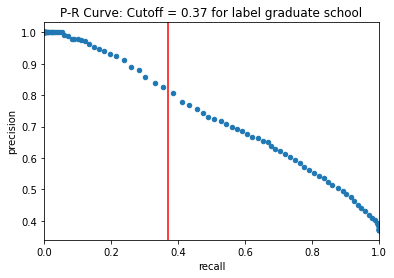

In [20]:
best_cut = get_best_cut_per_label(data_yhat, label)

# 6. Define DIA object

In [21]:
dia = BinaryDisparateImpactAnalysis(actual_column=f'{label}_target', predict_column=label, 
                              cutoff=best_cut, group_column='SEX')

# 7. Report Raw Confusion Matrices

The basic DIA procedure in this notebook is based on measurements found commonly in confusion matrices, so confusion matrices are calculated as a precursor to DIA and to provide a basic summary of the GBM's behavior in general and across eduction levels.

In [22]:
# Convert output to Pandas for printing purposes
dia.get_confusion_matrix(frame=data_yhat, print_frame=True, get_global_cm=True, convert_to_pandas=True)

Pandas Confusion Matrix:
              actual: 1  actual: 0
predicted: 1     2676.0     1689.0
predicted: 0     1038.0     4597.0


,actual: 1,actual: 0
predicted: 1,2676.0,1689.0
predicted: 0,1038.0,4597.0


#### Report confusion matrices by gender level 

Because race is unavailable in the UCI credit card data set, `SEX` level will be used to perform DIA.

#### Confusion matrix for `female`

In [23]:
# Convert output to Pandas for printing purposes
female_cm_dt = dia.get_confusion_matrix(frame=data_yhat, level='female', print_frame=True, convert_to_pandas=True)

Pandas Confusion Matrix:
              actual: 1  actual: 0
predicted: 1     1522.0     1118.0
predicted: 0      566.0     2588.0


#### Confusion matrix for `male`

In [24]:
# Convert output to Pandas for printing purposes
male_cm_dt = dia.get_confusion_matrix(frame=data_yhat, level='male', print_frame=True, convert_to_pandas=True)

Pandas Confusion Matrix:
              actual: 1  actual: 0
predicted: 1     1154.0      571.0
predicted: 0      472.0     2009.0


# 8. Disparate Impact Analysis (DIA)

To perform the following basic DIA many different values from the confusion matrices reflecting different prediction behavior are calculated. These metrics essentially help us understand the GBM's overall performance and how it behaves when predicting:

* Default correctly
* Non-default correctly
* Default incorrectly (type I errors)
* Non-default incorrectly (type II errors)

In a real-life lending scenario, type I errors essentially amount to false accusations of financial impropriety and type II errors result in awarding loans to undeserving customers. Both types of errors can be costly to the lender too. Type I errors likely result in lost interest and fees. Type II errors often result in write-offs.

#### Calculate and report metrics
This nested loop calculates all the metrics defined above for each education level.

In [25]:
metrics_frame = dia.get_metrics(data_yhat)
metrics_frame

,Groups,N,Adverse Impact,Accuracy,True Positive Rate,Precision,Specificity,Negative Predicted Value,False Positive Rate,False Discovery Rate,False Negative Rate,False Omissions Rate
,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪
0,female,5794,0.455644,0.709355,0.728927,0.576515,0.698327,0.820545,0.301673,0.423485,0.271073,0.179455
1,male,4206,0.410128,0.752021,0.709717,0.668985,0.778682,0.809754,0.221318,0.331014,0.290283,0.190246


#### Plot false negative rate by gender level 

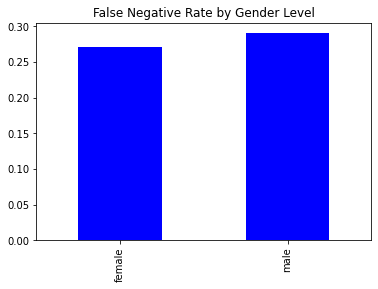

In [26]:
# Convert datatable to Pandas for plotting
metrics_frame_pandas = metrics_frame.to_pandas()
metrics_frame_pandas.index = metrics_frame_pandas["Groups"].values
metrics_frame_pandas.drop("Groups", axis=1, inplace=True)
_ = metrics_frame_pandas['False Negative Rate'].plot(kind='bar', color='b', title='False Negative Rate by Gender Level')

#### Calculate and report disparity
To calculate disparity we compare the confusion matrix for each gender level to the metrics for a user-defined reference level and to user-defined thresholds.

In [27]:
disp_frame = dia.get_disparity(frame=data_yhat, ref_level='male')
disp_frame

# Get unique levels for gender variable
gender_unique = dt.unique(data_yhat[:, 'SEX']).to_list()[0]

#small utility function to format pandas table output
def disparate_red(val):
   
   color = 'blue' if (dia.low_threshold < val < dia.high_threshold) else 'red'
   return 'color: %s' % color 

disp_frame_pd = disp_frame.to_pandas().drop(['Groups'], axis=1)
disp_frame_pd.index = gender_unique
disp_frame_pd.head()
# display results
disp_frame_pd.style.applymap(disparate_red)

,N,Adverse Impact Disparity,Marginal Error,Standardized Mean Difference,Accuracy Disparity,True Positive Rate Disparity,Precision Disparity,Specificity Disparity,Negative Predicted Value Disparity,False Positive Rate Disparity,False Discovery Rate Disparity,False Negative Rate Disparity,False Omissions Rate Disparity
female,5794,1.11098,-0.0455154,0.0903841,0.943264,1.02707,0.861775,0.896806,1.01333,1.36308,1.27935,0.933823,0.943278
male,4206,1,0,0,1,1,1,1,1,1,1,1,1


#### Plot false negative rate disparity

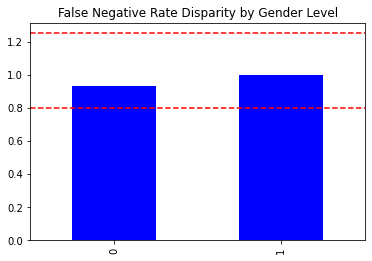

In [28]:
ax = disp_frame.to_pandas()['False Negative Rate Disparity'].plot(kind='bar', color='b', title='False Negative Rate Disparity by Gender Level')
_ = ax.axhline(dia.low_threshold, color='r', linestyle='--')
_ = ax.axhline(dia.high_threshold, color='r', linestyle='--')

#### Assess and report parity
A binary indication of parity for metrics is reported by simply checking whether disparity values are within the user-defined thresholds. Further parity indicators are defined as combinations of other disparity values:

* Type I Parity: Fairness in both FDR Parity and FPR Parity
* Type II Parity: Fairness in both FOR Parity and FNR Parity
* Equalized Odds: Fairness in both FPR Parity and TPR Parity
* Supervised Fairness: Fairness in both Type I and Type II Parity
* Overall Fairness: Fairness across all parities for all metrics

In [29]:
par_frame= dia.get_parity(frame=data_yhat, ref_level='male', get_disparity=True)
par_frame
# small utility function to format pandas table output    
def color_false_red(val):

    color = 'red' if not val else 'blue'
    return 'color: %s' % color 

par_frame_pd = par_frame.to_pandas()
par_frame_pd = par_frame_pd.drop(["Groups"], axis=1)
par_frame_pd.index = gender_unique + ["all"]
# display results
par_frame_pd.style.applymap(color_false_red)

,N,Adverse Impact Parity,Accuracy Parity,True Positive Rate Parity,Precision Parity,Specificity Parity,Negative Predicted Value Parity,False Positive Rate Parity,False Discovery Rate Parity,False Negative Rate Parity,False Omissions Rate Parity,Type I Parity,Type II Parity,Equalized Odds,Supervised Fairness,Overall Fairness
female,5794,True,True,True,True,True,True,False,False,True,True,False,True,False,False,False
male,4206,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
all,10000,True,True,True,True,True,True,False,False,True,True,False,True,False,False,False


#### Shutdown H2O

In [30]:
hmli.cluster().shutdown(prompt=False)

H2O session _sid_b470 closed.


#### Conclusion

This notebook outlines a basic approach to DIA in the context of multinomial models. 

In a complex, real-world machine learning project the hard-to-define phenomenas of sociological bias and unfairness can materialize in many ways and from many different sources. Although far from a flawless technique, the beauty of DIA is it is straightforward to implement, functions in a model-agnostic fashion on known labels and model predictions, and is applied in complex real-world fair lending situations, so it can probably be applied to your model too!